<a href="https://colab.research.google.com/github/Student-NitinRaj/Data-Analysis-HUB-/blob/main/Student_Score_Analyis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSet/Expanded_data_with_more_features.csv")
dt=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSet/Original_data_with_more_rows.csv")

In [4]:
df.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [5]:
df.tail()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93
30640,960,male,group B,some college,standard,none,married,never,no,1.0,school_bus,5 - 10,64,60,58


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [7]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [9]:
df=df.drop("Unnamed: 0", axis=1) # Remove unnamed col
print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female         NaN   bachelor's degree      standard     none   
1  female     group C        some college      standard      NaN   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


In [10]:
df["WklyStudyHours"] =df["WklyStudyHours"].str.replace("05-Oct","5-10") # Change weekly study hour
df.head() # data transformation

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


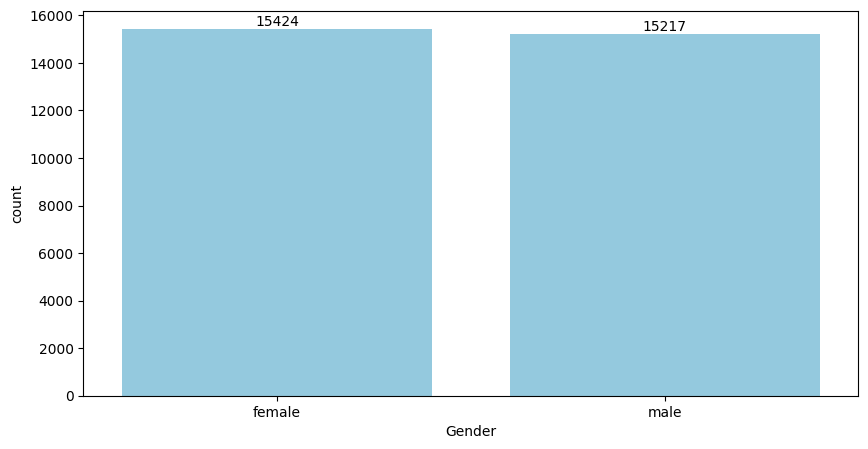

In [11]:
# gender distribution
plt.figure(figsize=(10,5))
ax=sns.countplot(x="Gender", data=df, color="skyblue") # Changed color to a single color string
ax.bar_label(ax.containers[0])
plt.show()

In [12]:
# from the above cart analyze from the female in the
#data is greater than male.

In [13]:
gb = df.groupby("ParentEduc").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


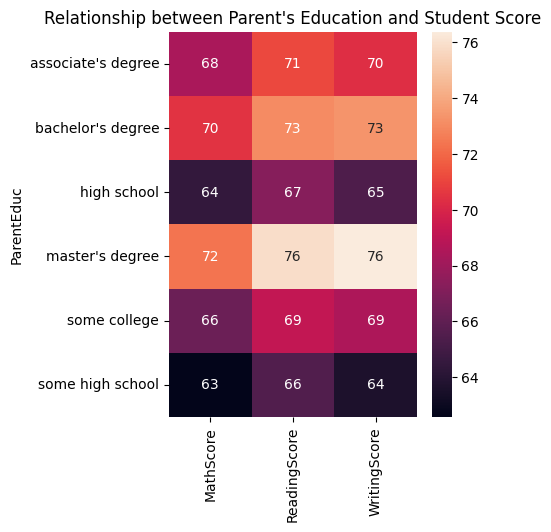

In [14]:
plt.figure(figsize=(4,5))
sns.heatmap(gb, annot=True)
plt.title("Relationship between Parent's Education and Student Score")
plt.show()

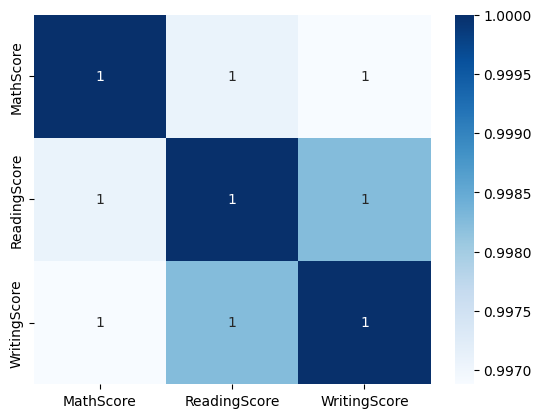

In [15]:
sns.heatmap(gb.corr(), annot=True, cmap="Blues")
plt.show()

From the above chart we have concluded that the eduction of the parents have a good impact on his exam score

In [16]:
# Checking Partent merital effect on child exam score
gb1 = df.groupby("ParentMaritalStatus").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(gb1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.657326     69.389575     68.420981
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


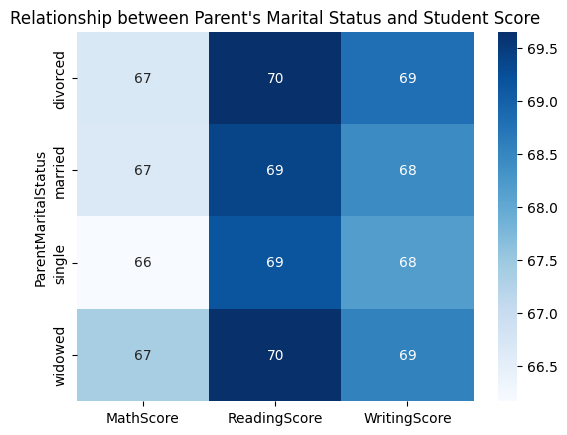

In [17]:
ax=sns.heatmap(gb1, annot=True, cmap="Blues")
plt.title("Relationship between Parent's Marital Status and Student Score")
plt.show()

From the above chart there is not or negligible empact on parent merital status

In [18]:
df.sample(3)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
25652,female,group C,NaN,standard,completed,divorced,sometimes,no,2.0,private,5 - 10,76,73,76
3794,male,group E,bachelor's degree,free/reduced,none,married,sometimes,yes,3.0,NaN,5 - 10,60,61,62
10224,male,group C,master's degree,free/reduced,none,married,never,no,3.0,school_bus,> 10,57,55,49


In [19]:
gb2 = df.groupby("PracticeSport").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(gb2)

               MathScore  ReadingScore  WritingScore
PracticeSport                                       
never          64.171079     68.337662     66.522727
regularly      67.839155     69.943019     69.604003
sometimes      66.274831     69.241307     68.072438


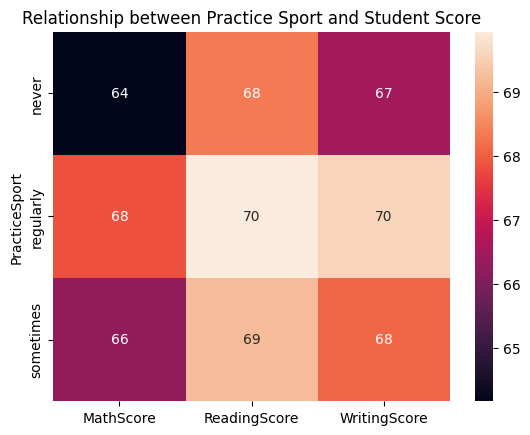

In [20]:
sns.heatmap(gb2, annot=True)
plt.title("Relationship between Practice Sport and Student Score")
plt.show()

From the upper anaysis and Visullization negligible impact on Practice sport

In [21]:
# Analyze the basis of first child
gb3 = df.groupby("IsFirstChild").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(gb3)

              MathScore  ReadingScore  WritingScore
IsFirstChild                                       
no            66.246832     69.132614     68.210887
yes           66.740646     69.542553     68.558484


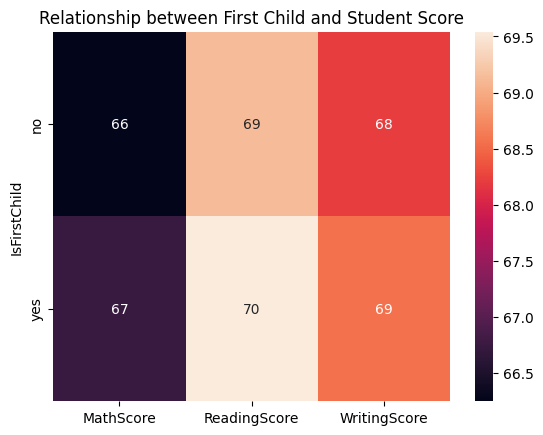

In [22]:
sns.heatmap(gb3, annot=True)
plt.title("Relationship between First Child and Student Score")
plt.show()

From the above analyis and visullization minimal imapact on 1at child

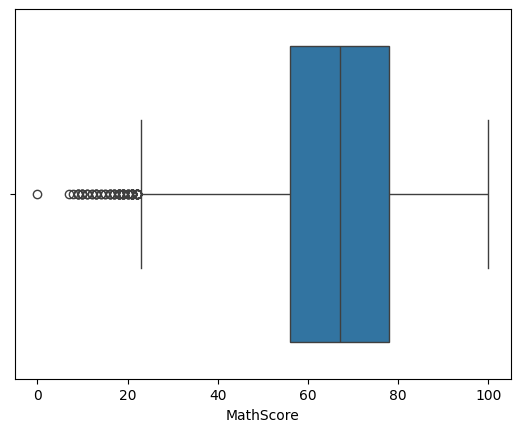

In [23]:
sns.boxplot( x="MathScore", data=df)
plt.show()

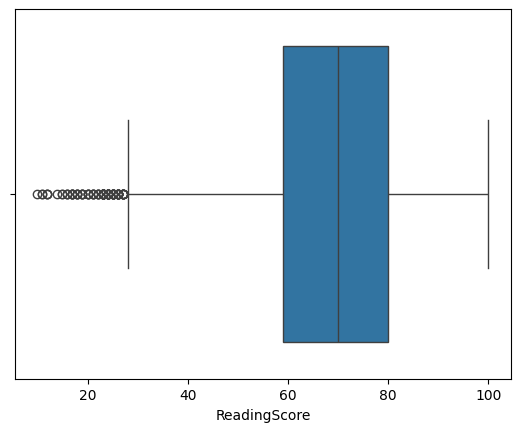

In [24]:
sns.boxplot(x="ReadingScore", data=df)
plt.show()

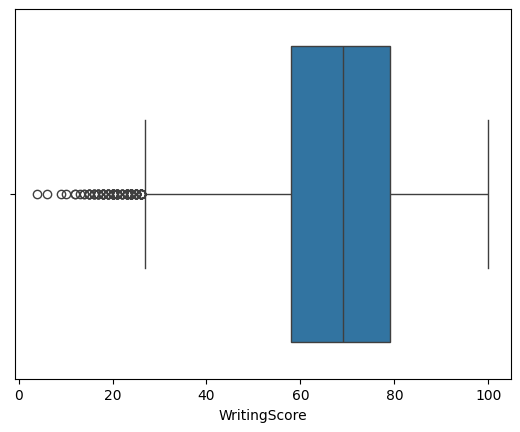

In [25]:
sns.boxplot(x="WritingScore", data=df)
plt.show()

In [26]:
print(df["EthnicGroup"].unique())

[nan 'group C' 'group B' 'group A' 'group D' 'group E']


Distribution of Ethnic Groups

In [ ]:
import matplotlib.pyplot as plt

groupA = df.loc[(df["EthnicGroup"] == "groupA")].count()
groupB = df.loc[(df["EthnicGroup"] == "groupB")].count()
groupC = df.loc[(df["EthnicGroup"] == "groupC")].count()
groupD = df.loc[(df["EthnicGroup"] == "groupD")].count()
groupE = df.loc[(df["EthnicGroup"] == "groupE")].count()

mlist = [
    groupA["EthnicGroup"],
    groupB["EthnicGroup"],
    groupC["EthnicGroup"],
    groupD["EthnicGroup"],
    groupE["EthnicGroup"]
]

print(mlist)

plt.pie(mlist, labels=["groupA", "groupB", "groupC", "groupD", "groupE"], autopct="%1.2f%%")
plt.title("Distribution of EthnicGroups")
plt.show()
# print(groupA)
# print(groupB)

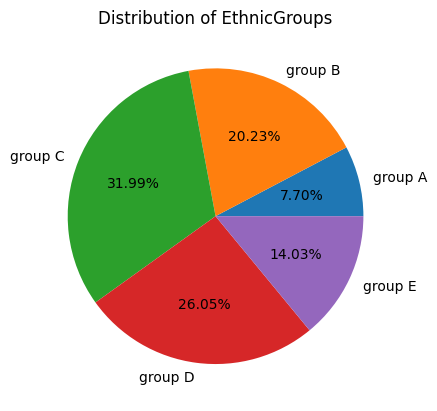

In [40]:
counts = df["EthnicGroup"].value_counts().reindex(["group A","group B","group C","group D","group E"], fill_value=0)
mlist = counts.tolist()
if sum(mlist) == 0:
    raise ValueError("All counts are 0. Check your category names in the DataFrame.")
plt.pie(mlist, labels=counts.index.tolist(), autopct="%1.2f%%")
plt.title("Distribution of EthnicGroups")
plt.show()

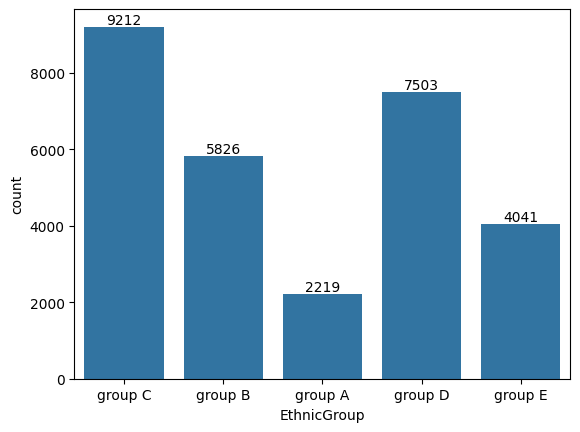

In [93]:
ax=sns.countplot(data=df, x="EthnicGroup") # ax take for vale fatch
ax.bar_label(ax.containers[0]) # for cheking value is correct is not
plt.show()